In [83]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from typing import Union
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from tqdm import tqdm
from tqdm import tqdm_notebook
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [33]:
# We start by downloading the dataset
path = kagglehub.dataset_download("arjunbhaybhang/marine-institute-tide-prediction-dataset")

print("Path to dataset files:", path)

files_in_directory = os.listdir(path)
print("Archivos en el directorio:", files_in_directory)

csv_file_path = os.path.join(path, 'Tide Prediction.csv')

data = pd.read_csv(csv_file_path)
data = data.iloc[1:]#The first row of the dataset is titles.

print(data.head())

Path to dataset files: C:\Users\angel\.cache\kagglehub\datasets\arjunbhaybhang\marine-institute-tide-prediction-dataset\versions\1
Archivos en el directorio: ['Tide Prediction.csv']


C:\Users\angel\AppData\Local\Temp\ipykernel_13116\4283588312.py:11: DtypeWarning: Columns (1,2,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(csv_file_path)


                   time   longitude  latitude               stationID  \
1  2017-01-01T00:10:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
2  2017-01-01T00:20:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
3  2017-01-01T00:30:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
4  2017-01-01T00:40:00Z  -10.101596  53.95219  Achill_Island_MODELLED   
5  2017-01-01T00:50:00Z  -10.101596  53.95219  Achill_Island_MODELLED   

  Water_Level Water_Level_ODM  
1        1.34           -1.23  
2         1.3           -1.27  
3        1.26           -1.31  
4        1.23           -1.34  
5        1.22           -1.35  


## Time Series Analysis

In [34]:
print('First row starts in: ' + data['time'].min(), 'last row is :' + data['time'].max())
# Data from 2017 to 2020
# 10 minutes margen between oone line to the next one

First row starts in: 2017-01-01T00:00:00Z last row is :2020-01-01T00:20:00Z


In [35]:
data['time'] = pd.to_datetime(data['time'])
data['longitude'] = pd.to_numeric(data['longitude'])
data['latitude'] = pd.to_numeric(data['latitude'])
data['Water_Level'] = pd.to_numeric(data['Water_Level'])
data['Water_Level_ODM'] = pd.to_numeric(data['Water_Level_ODM'])

In [36]:
data_located = data[data['stationID'] == 'Dingle_Harbour_MODELLED'] #We will only analyze data from an specific port!!

#Because of the high execution time, lets only consider data from one year
train = data_located[data_located['time'].dt.year == 2017]

In [37]:
#test data will be first week of 2018 (horizon)
data_2018 = data_located.loc[data_located['time'].dt.year == 2018]  # First week of 2018
test = data_2018[:1008] 
len(test) #Should be 1008: 6x24x7 

1008

In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52559 entries, 1997291 to 2049849
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             52559 non-null  datetime64[ns, UTC]
 1   longitude        52559 non-null  float64            
 2   latitude         52559 non-null  float64            
 3   stationID        52559 non-null  object             
 4   Water_Level      52559 non-null  float64            
 5   Water_Level_ODM  52559 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(4), object(1)
memory usage: 2.8+ MB


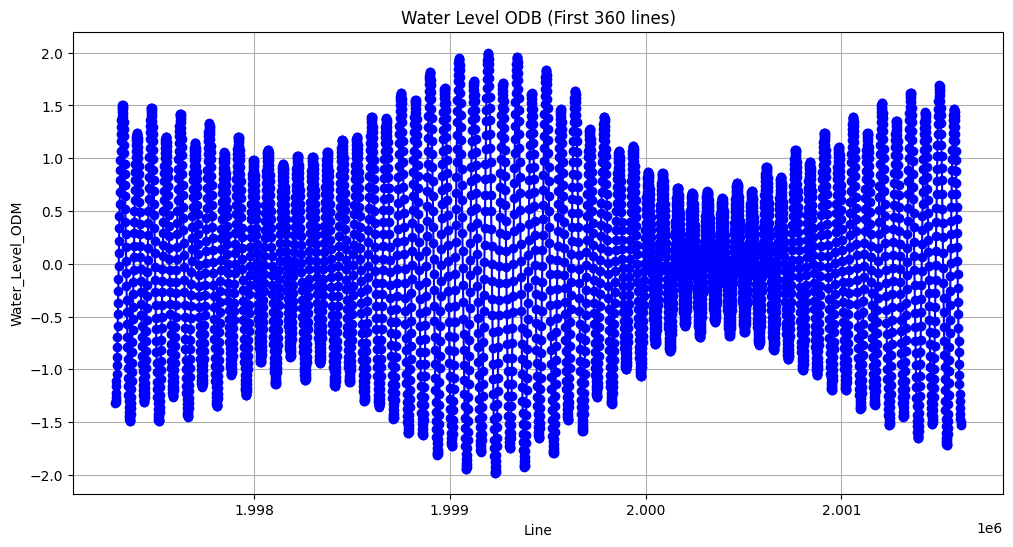

In [39]:
primeras_100 = train.head(4320)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

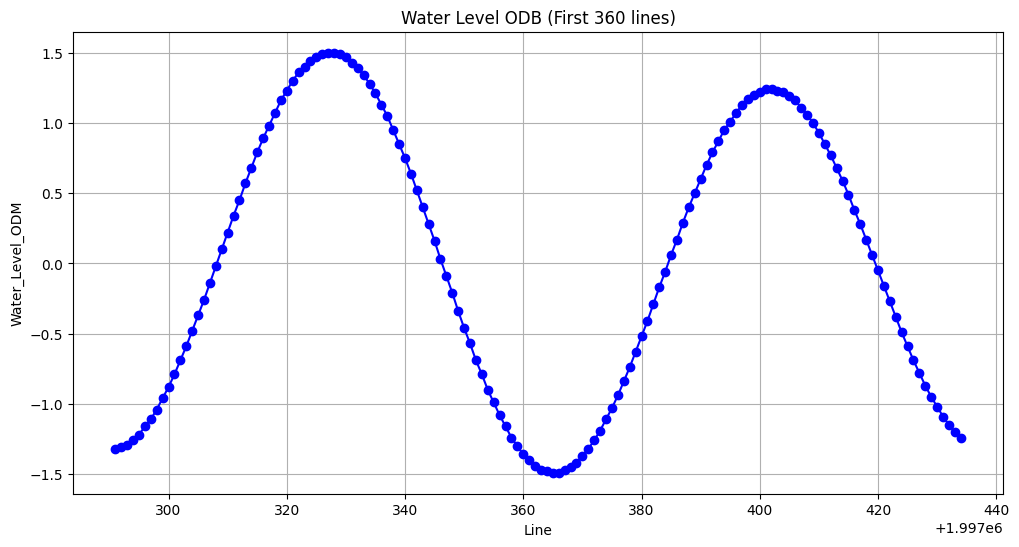

In [40]:
primeras_100 = train.head(144)

# This is the water lever over a day, we can see it seems to follow a patern
# This shows perfectly that in a day there are 2 high tides and 2 low tides
plt.figure(figsize=(12, 6))
plt.plot(primeras_100['Water_Level_ODM'], marker='o', linestyle='-', color='blue')
plt.title('Water Level ODB (First 360 lines)')
plt.xlabel('Line')
plt.ylabel('Water_Level_ODM')
plt.grid(True)
plt.show()

In [41]:
# In the previous graph we can obseve there are 2 season each day, but according to the theory, wides contain 4 different season at the same time
# The can be regular but this might not be a problem as time series are usually not too strict with this.

# First: 12 hours 25 minutes (74.5 rows)
# Second: 24 hours 50 minutes (149 rows)
# Third: 14.76 days (2.125,44 rows)
# Four: 365 days (52.560 rows) we will not consider this as we are only analyzing 2017 data

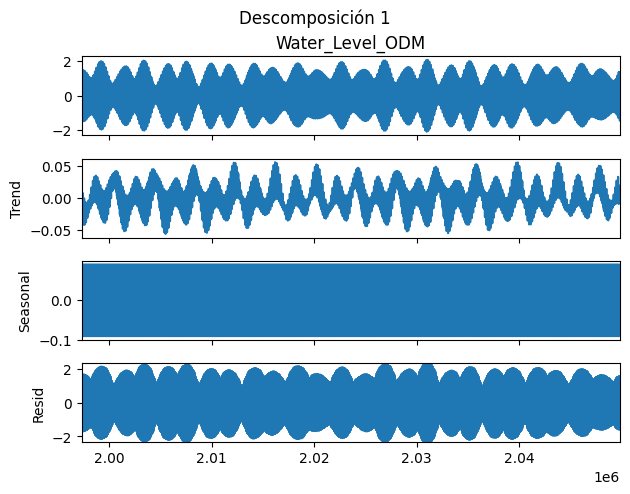

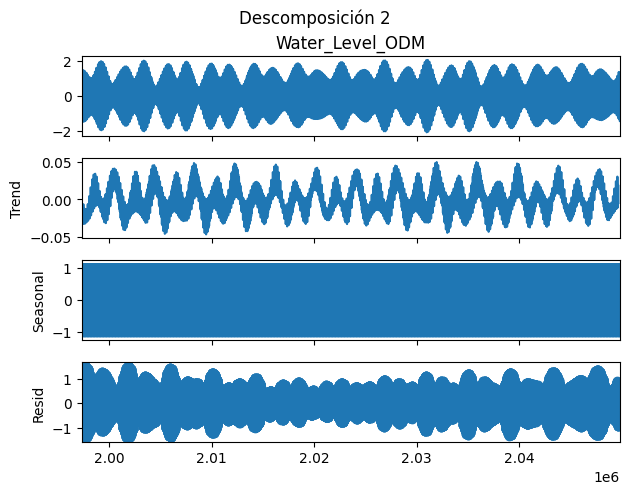

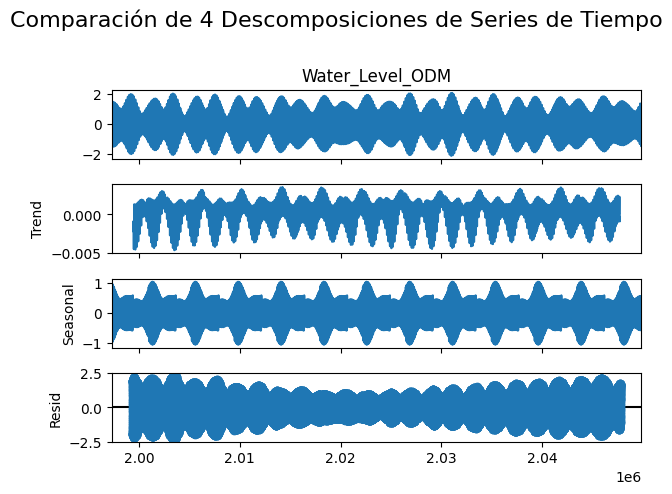

In [117]:
# Decomposition
# x must contain 2 complete cycles.
decomposition_1 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=150)
decomposition_2 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=298)
decomposition_3 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=4252)
# decomposition_4 = seasonal_decompose(train['Water_Level_ODM'], model='additive', period=52560*2)

# Graficar cada descomposición en su respectivo subplot
decomposition_1.plot().suptitle('Descomposición 1', x=0.5, y=1.02)
decomposition_2.plot().suptitle('Descomposición 2', x=0.5, y=1.02)
decomposition_3.plot().suptitle('Descomposición 3', x=0.5, y=1.02)
# decomposition_4.plot().suptitle('Descomposición 4', x=0.5, y=1.02)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Título principal
plt.suptitle('Comparación de 4 Descomposiciones de Series de Tiempo', fontsize=16, y=1.02)

plt.show()


Analysis for seasonal_decomposition:

1. Twice a day & Daily season:
    - Trend: close to 0 with small oscilations, stable, not strong increasing or decrasing, cyclic
    - Seasonality: no seasonality detected, this can be because there are more than 1 seasons
    - Residuals: residuals or random noise should be random, but there is an structures and patterns!!

2. Each 14.76 weeks:
    - Trend: allways so close to 0
    - Seasonality: The perios worked well, clean waves and repeating pattern
    - Residuals

In [43]:
# Analysis for yearly decomposition

# Observed: High var, lot of jumps, that can be because of the sensors-> missed data...
# Trend: Stable and flat during the whole data, means only change on the short run
#           Anomaly in an specific point: data error or something strange happened there
# Seasonality: Stable, simetric and repetitive, stationality is well detected.
# Residuals: Seems to be sparse but with patterns, that can be because it contains more that 1 seasonalitities  
#               It can be because the data is noisy itself, will later see the qq-plot!!      

In [44]:
# mstl = MSTL(train['Water_Level_ODM'], periods=[74*2+1, 149*2, 2125*2+1, 52560*2])
# result = mstl.fit()
# result.plot()

## ARMA

###  Identify the q order for MA

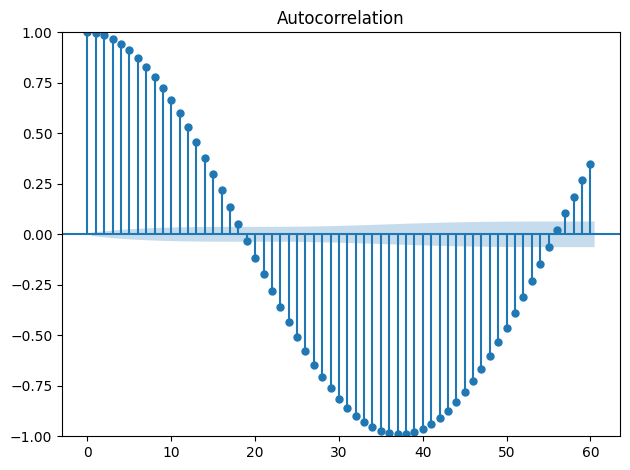

In [45]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(train['Water_Level_ODM'], lags=60);
plt.tight_layout()

ACF plot analysis: 
- there is autocorrelation between lags so it is not a random walk
- as coefficients become abruptly after a lag q (+-18?) -> not an MA(q) process
- using the first diference can be an option for the future, but if it doesnt get much better, take into account we are losing much info

### Identify the p order for the AR

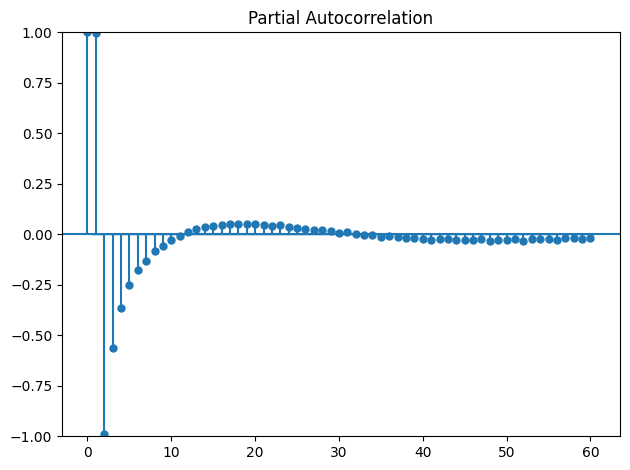

In [46]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(train['Water_Level_ODM'], lags=60);
plt.tight_layout()

Pacf plot analysis:
- Not a pure PA(p) process either as it follows a sinusodial pattern
- Let's try AIC 

### Select model with lowers AIC

In [47]:
ps = range(0, 20, 1) #From 0 to 3 with steps of 1
qs = range(0, 10, 1) #From 0 to 3 with steps of 1

order_list = list(product(ps, qs))

In [48]:
# def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
#     results = []
#     for order in tqdm_notebook(order_list):
#       try:
#           model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
#       except:
#         continue
#       aic = model.aic
#       results.append([order, aic])
#     result_df = pd.DataFrame(results)
#     result_df.columns = ['(p,q)', 'AIC']
#     #Sort in ascending order, lower AIC is better
#     result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
#     return result_df

# result_df = optimize_ARMA(train['Water_Level_ODM'], order_list)
# result_df

### Residuals Analysis

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


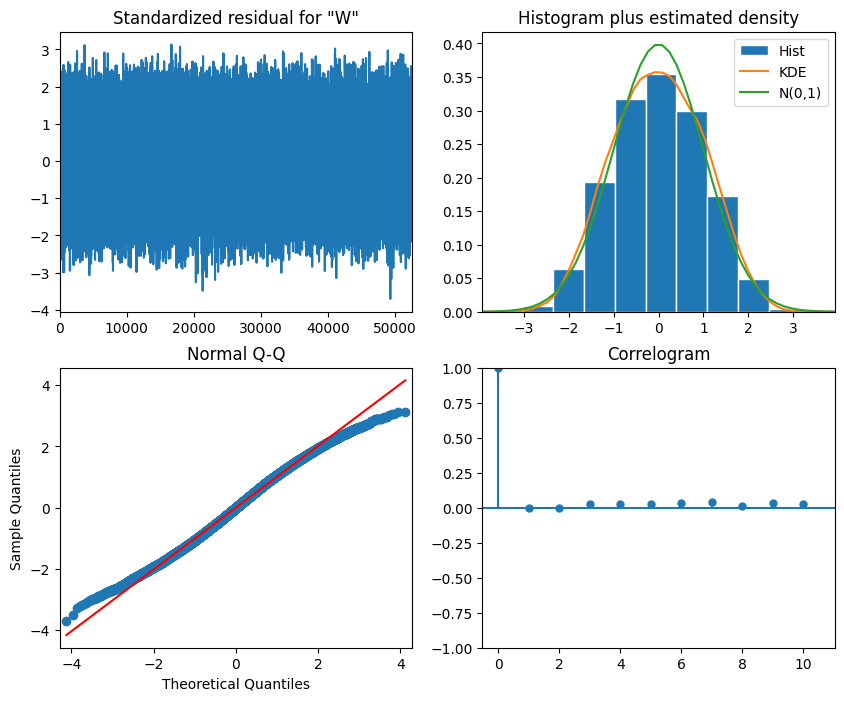

In [49]:
ARMA_model = SARIMAX(train['Water_Level_ODM'], order=(14,0 ,8), simple_differencing=False)
ARMA_model_fit = ARMA_model.fit(disp=False)
ARMA_model_fit.plot_diagnostics(figsize=(10, 8));

- in the q-q plot we can observe a pattern where in the extremes the resudials dont follow this expected distribution,
- the lack of autocorrelation between residuals means it fits correctly (model is acceptable)
- can it be because of outliers?

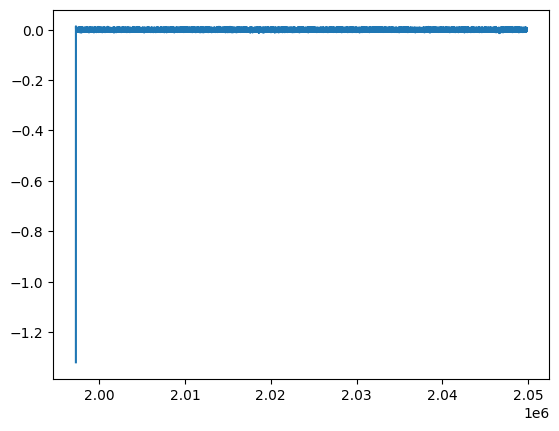

In [50]:
import matplotlib.pyplot as plt
plt.plot(ARMA_model_fit.resid)
plt.show()

In [51]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = ARMA_model_fit.resid #This is were residuals are stored
print( acorr_ljungbox(residuals, np.arange(1, 11, 1)))


      lb_stat  lb_pvalue
1    0.462888   0.496277
2    0.463112   0.793298
3    3.079591   0.379516
4    5.214783   0.265961
5    5.217534   0.389913
6   12.851046   0.045463
7   18.232561   0.010964
8   18.253817   0.019402
9   24.539961   0.003525
10  28.602589   0.001445


- 1-5 p-val>0.05 means model is correctly fitting for predicting in shorter lags
- for bigger lags the model shows autocorrelation -> model misses seasonality

## ARIMA

In [52]:
# def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
#     results = []
#     for order in tqdm_notebook(order_list):
#       try:
#           model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
#       except:
#         continue
#       aic = model.aic
#       results.append([order, aic])
#     result_df = pd.DataFrame(results)
#     result_df.columns = ['(p,q)', 'AIC']
#     #Sort in ascending order, lower AIC is better
#     result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
#     return result_df

# result_df = optimize_ARMA(train['Water_Level_ODM'], order_list)
# result_df

## SARIMAX

In [53]:
# def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
#     results = []
#     for order in tqdm_notebook(order_list):
#       try:
#           model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
#       except:
#         continue
#       aic = model.aic
#       results.append([order, aic])
#     result_df = pd.DataFrame(results)
#     result_df.columns = ['(p,q)', 'AIC']
#     #Sort in ascending order, lower AIC is better
#     result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
#     return result_df

# result_df = optimize_ARMA(train['Water_Level_ODM'], order_list)
# result_df

## FB Prophet

documentation in: https://facebook.github.io/prophet/docs/quick_start.html#python-api

In [90]:
train_2 = train.copy()
# train_2 = train_2.drop(columns=['longitude', 'latitude', 'stationID', 'Water_Level'])
# PF Prophet algorithms requires time column to be names 'ds' and the one to predict 'y'
train_2 = train_2.rename(columns={'time': 'ds', 'Water_Level_ODM': 'y'})

train_2['ds'] = train_2['ds'].dt.tz_localize(None)  # Remove timezone for prophet

In [113]:
prophet_model = Prophet(changepoint_prior_scale=0.05, seasonality_prior_scale=10.0)
# Add custom seasonalities (if you know your cycles)

prophet_model.add_seasonality(
    name='hourly', 
    period=1/24,  # Daily cycle
    fourier_order=5  # Higher = more flexible fit (3-10 typical)
)
prophet_model.seasonality_mode = 'additive'

prophet_model.fit(train_2)

19:31:06 - cmdstanpy - INFO - Chain [1] start processing
19:31:15 - cmdstanpy - INFO - Chain [1] done processing


In [114]:
future = prophet_model.make_future_dataframe(
    periods=7 * 24 * 6,  # 7 days * 24 hours * 6 intervals per hour (10 mins each)
    freq='10T',          # '10T' = 10 minutes
    include_history=False  # Optional: exclude training data
)
future.tail()

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


,ds
1003,2018-01-07 23:10:00
1004,2018-01-07 23:20:00
1005,2018-01-07 23:30:00
1006,2018-01-07 23:40:00
1007,2018-01-07 23:50:00


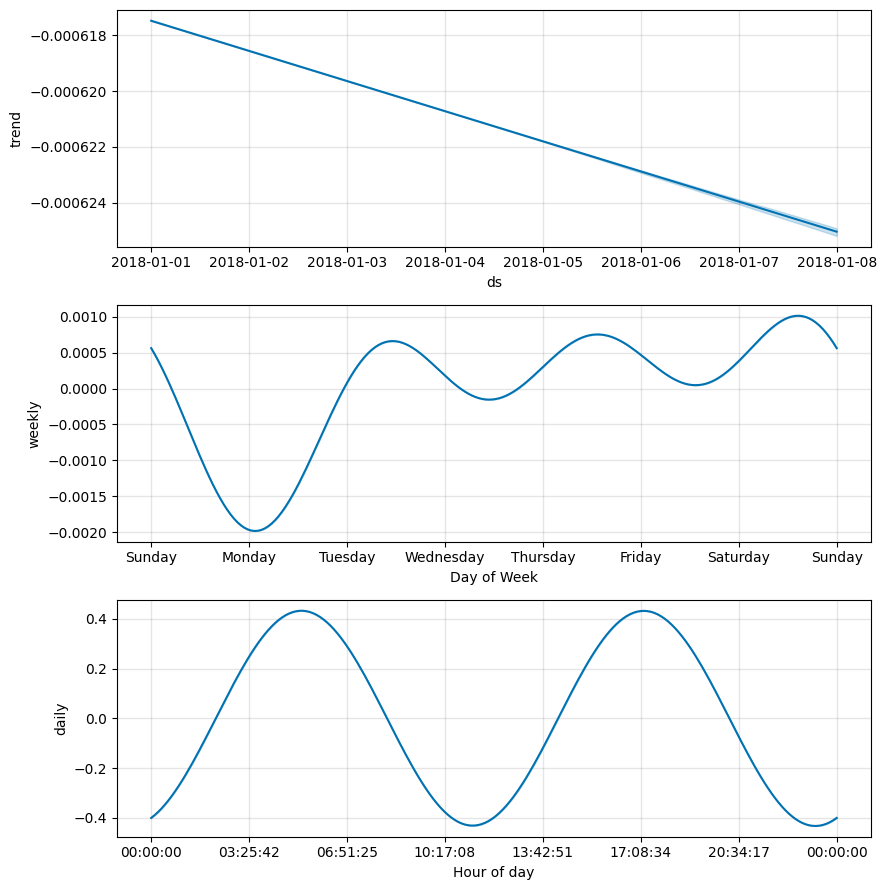

In [104]:
forecast = prophet_model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()
fig2 = prophet_model.plot_components(forecast)

## Forecasting summary

In [115]:
# Forecast 1008 steps ahead (10-min intervals = 7 days)
forecast = ARMA_model_fit.get_forecast(steps=1008)  # 1008 steps = 7 days
pred_ARMA = forecast.predicted_mean

# Optional: Add 2018 timestamps to the forecast
pred_ARMA.index = pd.date_range(
    start='2018-01-01 00:00:00+00:00',
    periods=1008,
    freq='10T'  # 10-minute frequency
)

test['ARMA_pred'] = pred_ARMA.values



pred_PFProphet = prophet_model.predict(future)
test['PF_Prophet_pred'] = pred_PFProphet['yhat'].values

c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\angel\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\angel\AppData\Local\Temp\ipykernel_13116\3920125450.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  pred_ARMA.index = pd.date_range(
C:\Users\angel\AppData\Local\Temp\ipykernel_13116\3920125450.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

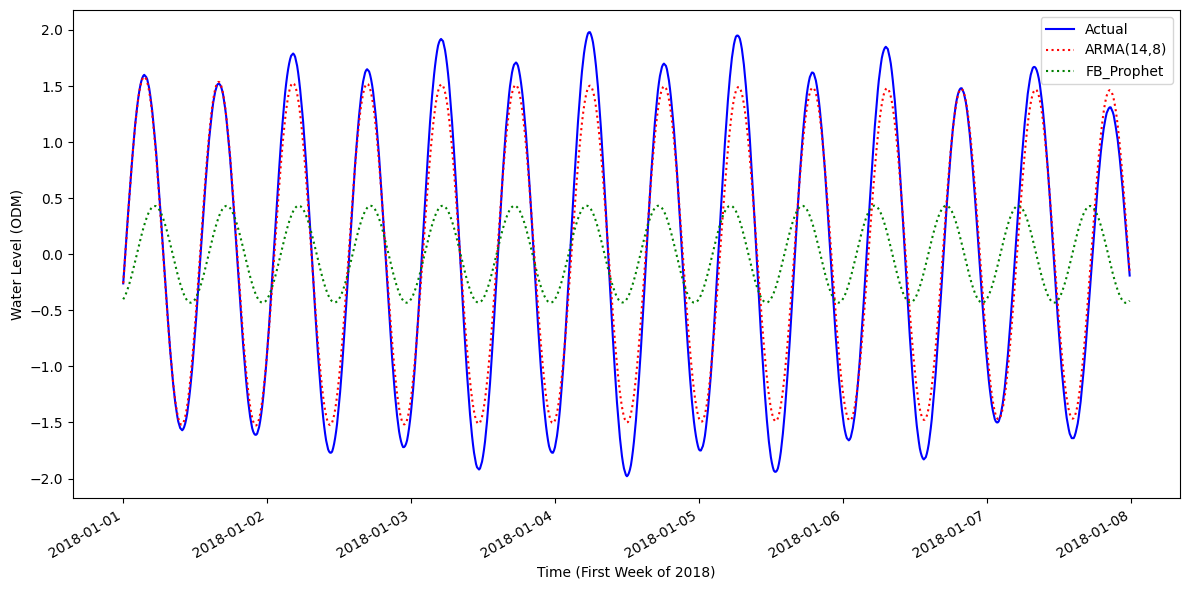

In [116]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual vs. predicted
ax.plot(test['time'], test['Water_Level_ODM'], 'b-', label='Actual')
ax.plot(test['time'], test['ARMA_pred'], 'r:', label='ARMA(14,8)')
ax.plot(test['time'], test['PF_Prophet_pred'], 'g:', label='FB_Prophet')

# Customize x-axis for 2018 timestamps
ax.set_xlabel('Time (First Week of 2018)')
ax.set_ylabel('Water Level (ODM)')
ax.legend(loc='best')

# Auto-format dates
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_13116\2625198752.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


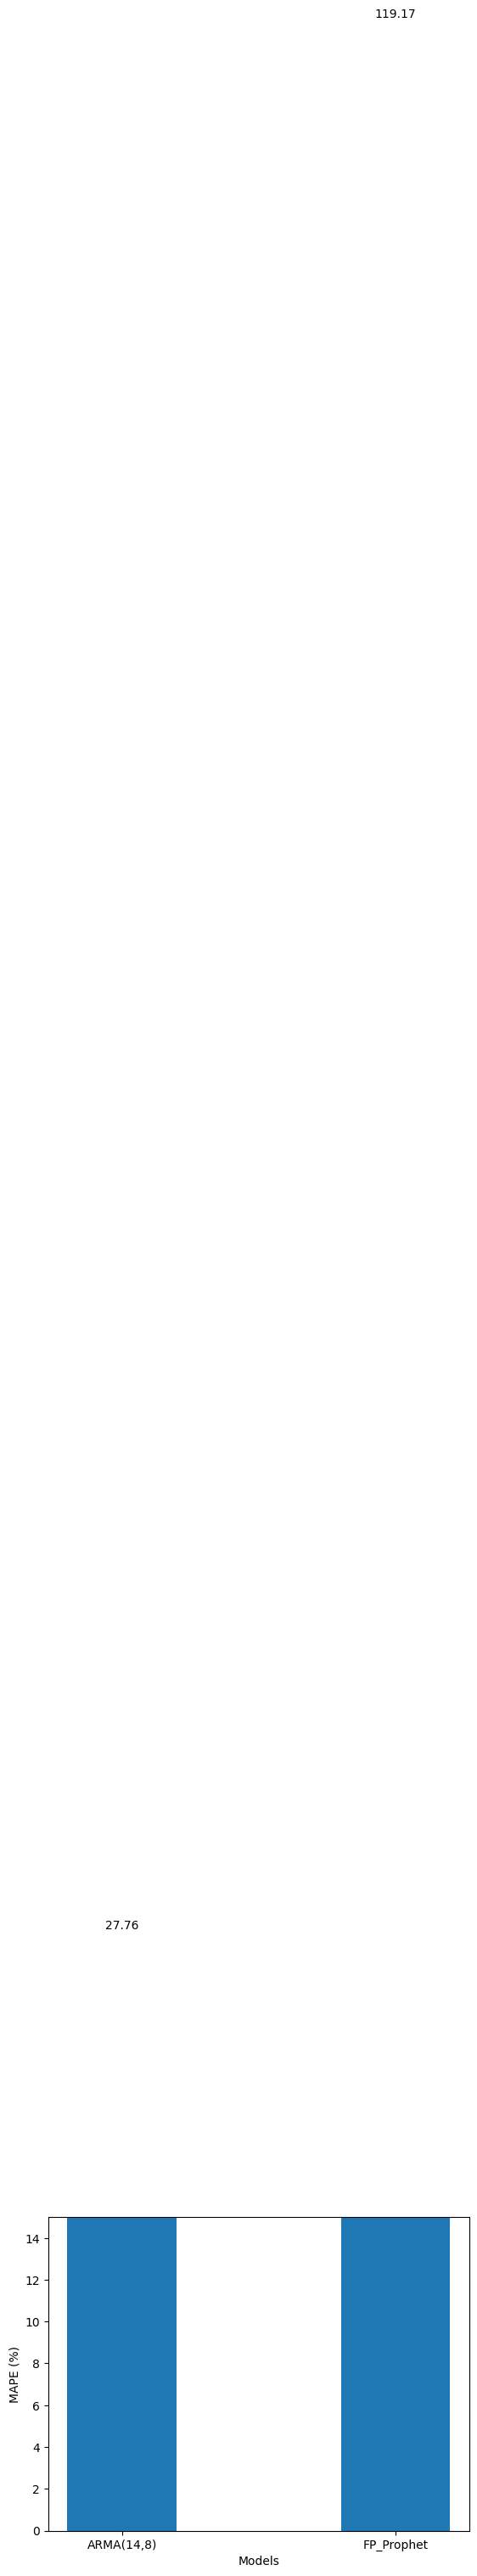

In [112]:
from sklearn.metrics import mean_absolute_percentage_error

mape_ARMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['ARMA_pred'])
# mape_ARIMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['ARIMA_pred'])
# mape_SARIMA = mean_absolute_percentage_error(test['Water_Level_ODM'], test['SARIMA_pred'])
mape_FP_Prophet = mean_absolute_percentage_error(test['Water_Level_ODM'], test['PF_Prophet_pred'])

fig, ax = plt.subplots()
x = ['ARMA(14,8)', 'FP_Prophet']
y = [mape_ARMA*100, mape_FP_Prophet*100]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()